# Kriging Interpolation - Performance Evaluation

Dieses Notebook evaluiert die Performance der Regression-Kriging Interpolation durch Vergleich der interpolierten Zeitreihen mit den echten Windgeschwindigkeiten.

**Metriken:**
- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)
- R² (Coefficient of Determination)
- Bias (Mittlere Abweichung)
- Korrelation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
#plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## 1. Daten laden

In [3]:
# Pfade
kriging_dir = Path('../data/kriging_stations')
station_data_dir = Path('/mnt/nvme1/synthetic/wind/era5_fric_wind_hourly_age')
meta_path = Path('/mnt/nvme1/synthetic/wind/wind_hourly_age_20251103/wind_parameter.csv')

# Zeitraum (aus Config)
test_start = '2023-07-24'
test_end = '2025-10-31'

print(f"Kriging Dateien: {len(list(kriging_dir.glob('kriging_*.csv')))}")
print(f"Zeitraum: {test_start} bis {test_end}")

Kriging Dateien: 160
Zeitraum: 2023-07-24 bis 2025-10-31


In [4]:
# Metadaten laden
meta_df = pd.read_csv(meta_path, sep=';')
meta_df['park_id'] = meta_df['park_id'].astype(str).str.zfill(5)
meta_df = meta_df.set_index('park_id')

print(f"Metadaten: {len(meta_df)} Stationen")
meta_df.head()

Metadaten: 203 Stationen


,longitude,latitude,altitude,commissioning_date
park_id,,,,
00096,12.8518,52.9437,50.0,2015-06-25
00161,7.4202,50.4237,75.0,2015-01-23
00164,13.9908,53.0316,54.0,2015-01-07
00183,13.4344,54.6791,42.0,2000-11-20
00198,11.2920,51.3744,164.0,2013-01-11


In [5]:
# Alle Kriging-Dateien finden
kriging_files = sorted(kriging_dir.glob('kriging_*.csv'))
station_ids = [f.stem.replace('kriging_', '') for f in kriging_files]

print(f"Gefundene Stationen: {len(station_ids)}")
print(f"Beispiel-IDs: {station_ids[:5]}")

Gefundene Stationen: 160
Beispiel-IDs: ['00096', '00161', '00164', '00183', '00198']


## 2. Performance-Metriken berechnen

In [ ]:
def calculate_metrics(y_true, y_pred):
    """Berechne Performance-Metriken."""
    # Remove NaN values
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true_clean = y_true[mask]
    y_pred_clean = y_pred[mask]

    if len(y_true_clean) < 10:
        return {
            'rmse': np.nan,
            'mae': np.nan,
            'r2': np.nan,
            'bias': np.nan,
            'correlation': np.nan,
            'n_samples': len(y_true_clean)
        }

    rmse = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))
    mae = mean_absolute_error(y_true_clean, y_pred_clean)
    r2 = r2_score(y_true_clean, y_pred_clean)
    bias = np.mean(y_pred_clean - y_true_clean)
    corr, _ = pearsonr(y_true_clean, y_pred_clean)

    return {
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'bias': bias,
        'correlation': corr,
        'n_samples': len(y_true_clean)
    }

In [ ]:
# Performance für alle Stationen berechnen
results = []

for station_id in station_ids:
    # Kriging-Daten laden
    kriging_file = kriging_dir / f'kriging_{station_id}.csv'
    df_kriging = pd.read_csv(kriging_file, parse_dates=['timestamp'])
    df_kriging = df_kriging.set_index('timestamp')

    # Echte Daten laden
    station_file = station_data_dir / f'synth_{station_id}.csv'
    df_station = pd.read_csv(station_file, sep=';', parse_dates=['timestamp'])
    df_station = df_station.set_index('timestamp')

    # Zeitraum filtern
    df_station = df_station.loc[test_start:test_end]

    # Merge auf gemeinsame Zeitstempel
    df_merged = df_kriging.join(df_station[['wind_speed']], how='inner', rsuffix='_true')

    # Metriken berechnen
    metrics = calculate_metrics(
        df_merged['wind_speed'].values,
        df_merged['wind_speed_kriging'].values
    )

    # Metadaten hinzufügen
    result = {
        'station_id': station_id,
        'latitude': meta_df.loc[station_id, 'latitude'],
        'longitude': meta_df.loc[station_id, 'longitude'],
        'altitude': meta_df.loc[station_id, 'altitude'],
        **metrics
    }
    results.append(result)

# DataFrame erstellen
results_df = pd.DataFrame(results)
print(f"\nEvaluierung abgeschlossen für {len(results_df)} Stationen")
results_df.head(10)


Evaluierung abgeschlossen für 160 Stationen


,station_id,latitude,longitude,altitude,rmse,mae,r2,bias,correlation,n_samples
0,00096,52.9437,12.8518,50.0,1.704009,1.411650,-0.687980,1.357486,0.751926,19753
1,00161,50.4237,7.4202,75.0,1.855946,1.517428,-0.592817,1.215773,0.531568,19753
2,00164,53.0316,13.9908,54.0,1.662143,1.268612,0.236691,0.203929,0.585230,19753
3,00183,54.6791,13.4344,42.0,4.431164,3.456542,-0.465781,-3.105288,0.507621,19753
4,00198,51.3744,11.2920,164.0,1.463026,1.157095,0.495385,0.539074,0.750942,19753
5,00232,48.4253,10.9417,462.0,1.873024,1.480481,0.108261,1.036104,0.658733,19753
6,00282,49.8743,10.9206,240.0,1.924396,1.607076,-1.215139,1.508184,0.633369,19753
7,00298,54.3405,12.7108,3.0,1.920132,1.495076,0.403594,-0.628817,0.686717,19753
8,00303,52.0613,13.4997,55.0,1.914995,1.500047,0.044773,0.766478,0.608832,19753
9,00342,52.3170,8.1694,103.0,1.420747,1.116492,0.525635,0.359417,0.745893,19753


## 3. Zusammenfassung der Ergebnisse

In [8]:
# Statistiken
summary = results_df[['rmse', 'mae', 'r2', 'bias', 'correlation']].describe()
print("\n" + "="*60)
print("ZUSAMMENFASSUNG DER PERFORMANCE-METRIKEN")
print("="*60)
print(summary)
print("\n" + "="*60)
print(f"Durchschnittliche RMSE: {results_df['rmse'].mean():.3f} m/s")
print(f"Durchschnittliche MAE:  {results_df['mae'].mean():.3f} m/s")
print(f"Durchschnittliches R²:  {results_df['r2'].mean():.3f}")
print(f"Durchschnittliche Korr: {results_df['correlation'].mean():.3f}")
print(f"Durchschnittlicher Bias: {results_df['bias'].mean():.3f} m/s")
print("="*60)


ZUSAMMENFASSUNG DER PERFORMANCE-METRIKEN
             rmse         mae          r2        bias  correlation
count  160.000000  160.000000  160.000000  160.000000   160.000000
mean     1.993991    1.570693   -0.040777   -0.000337     0.633355
std      1.057742    0.868244    0.786837    1.418256     0.111105
min      1.103181    0.862434   -4.813499   -6.758909     0.243850
25%      1.457176    1.144411   -0.235627   -0.342919     0.566189
50%      1.679095    1.327827    0.191202    0.379175     0.651473
75%      1.988763    1.565451    0.422789    0.829672     0.711055
max      8.203061    6.859952    0.611333    2.126602     0.835782

Durchschnittliche RMSE: 1.994 m/s
Durchschnittliche MAE:  1.571 m/s
Durchschnittliches R²:  -0.041
Durchschnittliche Korr: 0.633
Durchschnittlicher Bias: -0.000 m/s


## 4. Visualisierungen

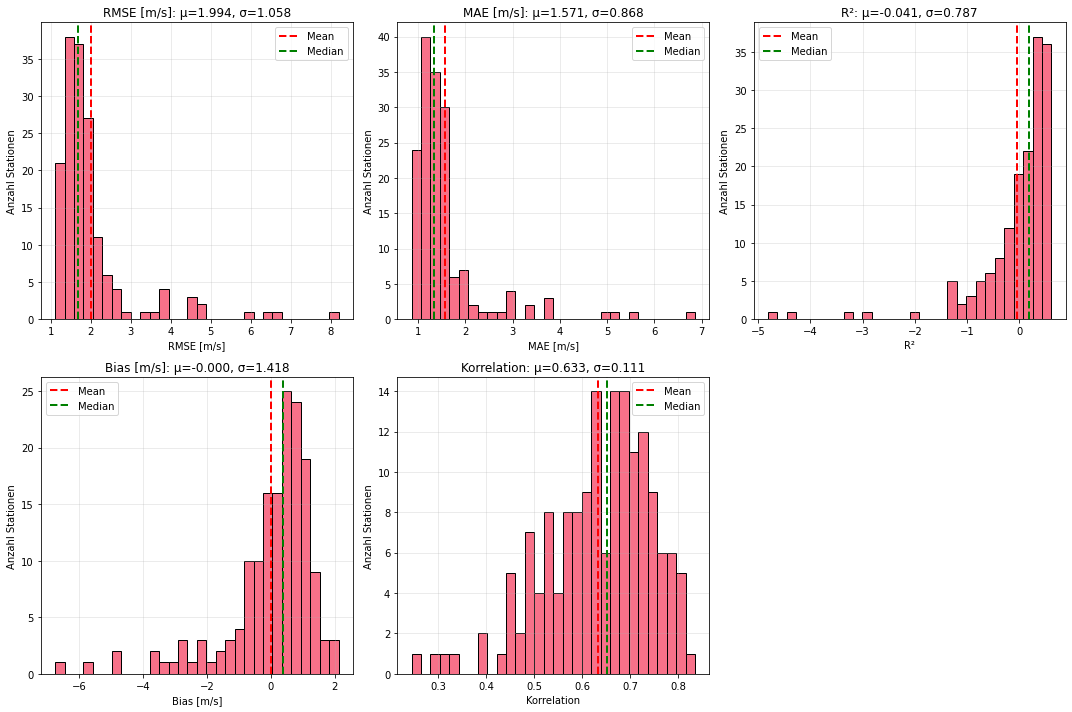

In [9]:
# Histogramme der Metriken
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

metrics_to_plot = ['rmse', 'mae', 'r2', 'bias', 'correlation']
titles = ['RMSE [m/s]', 'MAE [m/s]', 'R²', 'Bias [m/s]', 'Korrelation']

for idx, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    ax = axes[idx // 3, idx % 3]
    results_df[metric].hist(bins=30, ax=ax, edgecolor='black')
    ax.axvline(results_df[metric].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
    ax.axvline(results_df[metric].median(), color='green', linestyle='--', linewidth=2, label='Median')
    ax.set_xlabel(title)
    ax.set_ylabel('Anzahl Stationen')
    ax.set_title(f'{title}: μ={results_df[metric].mean():.3f}, σ={results_df[metric].std():.3f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Leere Subplot entfernen
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.savefig('kriging_metrics_histograms.png', dpi=300, bbox_inches='tight')
plt.show()

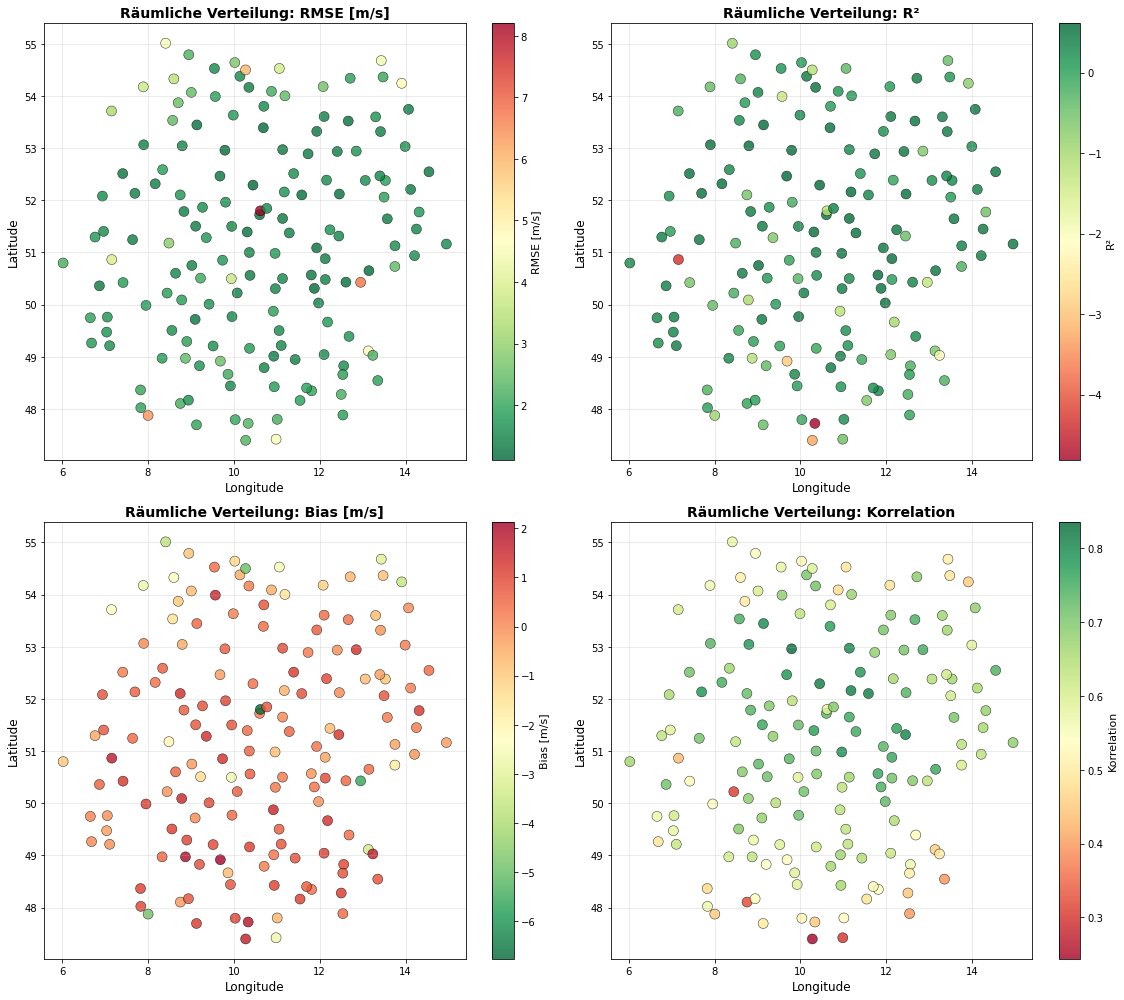

In [ ]:
# Räumliche Verteilung der Metriken
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

metrics_spatial = [('rmse', 'RMSE [m/s]'), ('r2', 'R²'),
                   ('bias', 'Bias [m/s]'), ('correlation', 'Korrelation')]

for idx, (metric, title) in enumerate(metrics_spatial):
    ax = axes[idx // 2, idx % 2]
    scatter = ax.scatter(results_df['longitude'], results_df['latitude'],
                        c=results_df[metric], s=100, cmap='RdYlGn_r' if metric in ['rmse', 'bias'] else 'RdYlGn',
                        edgecolors='black', linewidth=0.5, alpha=0.8)
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.set_title(f'Räumliche Verteilung: {title}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label(title, fontsize=11)

plt.tight_layout()
plt.savefig('kriging_spatial_performance.png', dpi=300, bbox_inches='tight')
plt.show()

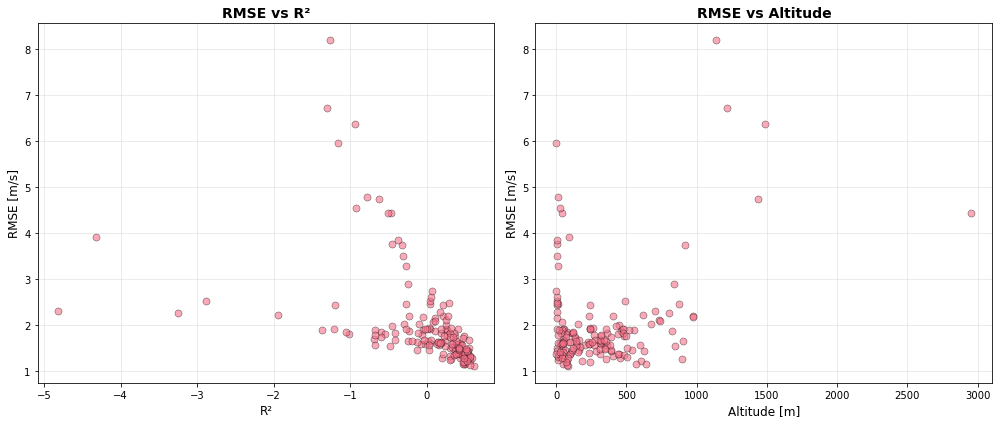

In [11]:
# Scatter-Plot: Beziehung zwischen Metriken
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# RMSE vs R²
axes[0].scatter(results_df['r2'], results_df['rmse'], alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('R²', fontsize=12)
axes[0].set_ylabel('RMSE [m/s]', fontsize=12)
axes[0].set_title('RMSE vs R²', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Altitude vs RMSE
axes[1].scatter(results_df['altitude'], results_df['rmse'], alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('Altitude [m]', fontsize=12)
axes[1].set_ylabel('RMSE [m/s]', fontsize=12)
axes[1].set_title('RMSE vs Altitude', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kriging_metric_relationships.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Top/Bottom Stationen

In [12]:
# Top 10 Stationen (beste RMSE)
print("\n" + "="*60)
print("TOP 10 STATIONEN (niedrigste RMSE)")
print("="*60)
top10 = results_df.nsmallest(10, 'rmse')[['station_id', 'rmse', 'mae', 'r2', 'correlation', 'altitude']]
print(top10.to_string(index=False))

print("\n" + "="*60)
print("BOTTOM 10 STATIONEN (höchste RMSE)")
print("="*60)
bottom10 = results_df.nlargest(10, 'rmse')[['station_id', 'rmse', 'mae', 'r2', 'correlation', 'altitude']]
print(bottom10.to_string(index=False))
print("="*60)


TOP 10 STATIONEN (niedrigste RMSE)
station_id     rmse      mae       r2  correlation  altitude
     00662 1.103181 0.862434 0.611333     0.811612      81.0
     04745 1.143010 0.918855 0.560282     0.835782      75.0
     00591 1.148343 0.888677 0.492424     0.769962      45.0
     03166 1.150728 0.906132 0.478204     0.756358     639.0
     02261 1.157387 0.913644 0.503934     0.742180     565.0
     05349 1.205983 0.943375 0.474796     0.741341      73.0
     03821 1.210361 0.957455 0.481766     0.732675     244.0
     00656 1.225227 0.947823 0.499294     0.727741     607.0
     05546 1.228822 0.955418 0.524083     0.734672     187.0
     03126 1.237068 1.001403 0.302643     0.810478      79.0

BOTTOM 10 STATIONEN (höchste RMSE)
station_id     rmse      mae        r2  correlation  altitude
     00722 8.203061 6.859952 -1.266058     0.575082    1135.0
     01358 6.710373 5.658144 -1.297354     0.636840    1213.0
     01346 6.363097 5.055297 -0.931930     0.454544    1486.0
     0296

## 6. Zeitreihen-Beispiele

ValueError: Multi-dimensional indexing (e.g. `obj[:, None]`) is no longer supported. Convert to a numpy array before indexing instead.

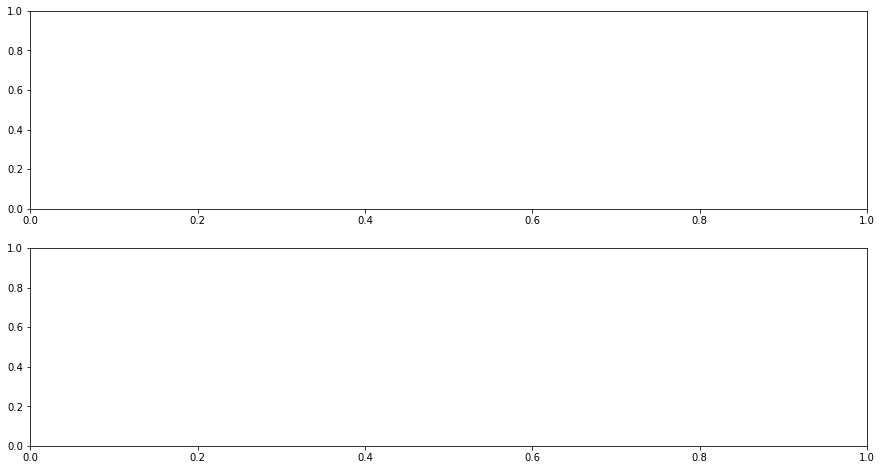

In [13]:
# Beispiel-Plots für beste und schlechteste Station
def plot_timeseries_comparison(station_id, title_suffix=''):
    """Plot Zeitreihenvergleich für eine Station."""
    # Kriging-Daten
    kriging_file = kriging_dir / f'kriging_{station_id}.csv'
    df_kriging = pd.read_csv(kriging_file, parse_dates=['timestamp'])
    df_kriging = df_kriging.set_index('timestamp')

    # Echte Daten
    station_file = station_data_dir / f'synth_{station_id}.csv'
    df_station = pd.read_csv(station_file, sep=';', parse_dates=['timestamp'])
    df_station = df_station.set_index('timestamp')
    df_station = df_station.loc[test_start:test_end]

    # Merge
    df_merged = df_kriging.join(df_station[['wind_speed']], how='inner', rsuffix='_true')

    # Plot nur einen Monat für bessere Sichtbarkeit
    sample_period = df_merged.iloc[:720]  # Erste 30 Tage

    fig, axes = plt.subplots(2, 1, figsize=(15, 8))

    # Zeitreihe
    axes[0].plot(sample_period.index, sample_period['wind_speed'],
                label='Echte Windgeschwindigkeit', alpha=0.7, linewidth=1.5)
    axes[0].plot(sample_period.index, sample_period['wind_speed_kriging'],
                label='Kriging Interpolation', alpha=0.7, linewidth=1.5)
    axes[0].set_ylabel('Windgeschwindigkeit [m/s]', fontsize=11)
    axes[0].set_title(f'Station {station_id} {title_suffix} - Zeitreihenvergleich (erste 30 Tage)',
                     fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # Scatter-Plot
    axes[1].scatter(df_merged['wind_speed'], df_merged['wind_speed_kriging'],
                   alpha=0.3, s=10, edgecolors='none')

    # 1:1 Linie
    max_val = max(df_merged['wind_speed'].max(), df_merged['wind_speed_kriging'].max())
    axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='1:1 Linie')

    axes[1].set_xlabel('Echte Windgeschwindigkeit [m/s]', fontsize=11)
    axes[1].set_ylabel('Kriging Interpolation [m/s]', fontsize=11)
    axes[1].set_title('Scatter-Plot: Echt vs. Kriging', fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_aspect('equal', adjustable='box')

    # Metriken als Text
    station_metrics = results_df[results_df['station_id'] == station_id].iloc[0]
    textstr = f"RMSE: {station_metrics['rmse']:.3f} m/s\n"
    textstr += f"MAE: {station_metrics['mae']:.3f} m/s\n"
    textstr += f"R²: {station_metrics['r2']:.3f}\n"
    textstr += f"Corr: {station_metrics['correlation']:.3f}"
    axes[1].text(0.05, 0.95, textstr, transform=axes[1].transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.savefig(f'kriging_example_{station_id}.png', dpi=300, bbox_inches='tight')
    plt.show()

# Beste Station
best_station = results_df.nsmallest(1, 'rmse').iloc[0]['station_id']
plot_timeseries_comparison(best_station, '(Beste RMSE)')

# Schlechteste Station
worst_station = results_df.nlargest(1, 'rmse').iloc[0]['station_id']
plot_timeseries_comparison(worst_station, '(Schlechteste RMSE)')

## 7. Ergebnisse speichern

In [ ]:
# Ergebnisse als CSV speichern
output_file = 'kriging_evaluation_results.csv'
results_df.to_csv(output_file, index=False)
print(f"\nErgebnisse gespeichert in: {output_file}")

# Zusammenfassung als Text speichern
with open('kriging_evaluation_summary.txt', 'w') as f:
    f.write("="*60 + "\n")
    f.write("KRIGING INTERPOLATION - PERFORMANCE EVALUATION\n")
    f.write("="*60 + "\n\n")
    f.write(f"Anzahl Stationen: {len(results_df)}\n")
    f.write(f"Zeitraum: {test_start} bis {test_end}\n\n")
    f.write("Durchschnittliche Metriken:\n")
    f.write("-" * 30 + "\n")
    f.write(f"RMSE:        {results_df['rmse'].mean():.4f} ± {results_df['rmse'].std():.4f} m/s\n")
    f.write(f"MAE:         {results_df['mae'].mean():.4f} ± {results_df['mae'].std():.4f} m/s\n")
    f.write(f"R²:          {results_df['r2'].mean():.4f} ± {results_df['r2'].std():.4f}\n")
    f.write(f"Bias:        {results_df['bias'].mean():.4f} ± {results_df['bias'].std():.4f} m/s\n")
    f.write(f"Korrelation: {results_df['correlation'].mean():.4f} ± {results_df['correlation'].std():.4f}\n")
    f.write("\n" + "="*60 + "\n")

print("Zusammenfassung gespeichert in: kriging_evaluation_summary.txt")
print("\n✅ Evaluation abgeschlossen!")